# 03d — Shot-Type Classification: Ablation Study

Systematic ablations on ShuttleSet shot-type classification (17 classes).
Same 8 train / 2 held-out split throughout. Each ablation saves results to
`results/ablations/{name}.json` immediately — restart kernel and skip to §9 to
view all results without retraining.

| # | Ablation | Description |
|---|----------|-------------|
| 1 | Baseline | 34 nodes, L2 features, no shuttle, no hitter |
| 2 | + Hitter | Binary is_hitter channel (front vs back perspective) |
| 3a | + Shuttle (graph) | Shuttle as virtual node 34 in skeleton graph |
| 3b | + Shuttle (cross-attn) | Separate shuttle stream with cross-attention fusion |
| 4 | + Variable window | Prev/next shot hit frames instead of fixed T=32 |
| 5 | Single-player (negative) | 17 nodes only — confirm dual-player is better |

## §1 — Setup & Colab Detection

In [1]:
import os, sys, json, copy, zipfile, time
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT   = Path('/content/drive/MyDrive/Baddiev2')
    PROJECT_PATH = Path('/content/Baddiev2')
    ZIP_PATH     = DRIVE_ROOT / 'baddiev2_colab.zip'
    if not (PROJECT_PATH / 'src').exists():
        print('Extracting project files...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
    sys.path.insert(0, str(PROJECT_PATH))
    os.chdir(PROJECT_PATH)

    import src.config as _cfg
    _cfg.MODELS_DIR            = DRIVE_ROOT / 'models'
    _cfg.RESULTS_DIR           = DRIVE_ROOT / 'results'
    _cfg.SS_SKELETONS_GDINO    = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_skeletons_gdino'
    _cfg.SS_SHUTTLES           = DRIVE_ROOT / 'datasets_preprocessing' / 'shuttleset_shuttles'
    _cfg.FB_ANNOTATIONS        = (
        DRIVE_ROOT / 'datasets' / 'FineBadminton-dataset' / 'dataset' /
        'transformed_combined_rounds_output_en_evals_translated.json'
    )
    _cfg.SS_CSV_ROOT   = DRIVE_ROOT / 'datasets' / 'ShuttleSet' / 'set'
    _cfg.SS_MATCH_CSV  = _cfg.SS_CSV_ROOT / 'match.csv'
    _cfg.SS_SPLIT_JSON = PROJECT_PATH / 'datasets_preprocessing' / 'shuttleset_split.json'
    _cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _cfg.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Drive root: {DRIVE_ROOT}')
else:
    sys.path.insert(0, os.path.abspath('..'))
    DRIVE_ROOT = Path('..')
    print('Local run')

Mounted at /content/drive
Extracting project files...
Drive root: /content/drive/MyDrive/Baddiev2


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, accuracy_score

from src.config import (
    get_config, FEATURE_DIMS, FEATURE_DIMS_WITH_HITTER,
    SS_SKELETONS_GDINO, SS_SHUTTLES, SS_SPLIT_JSON,
    SHOT_TYPES, NUM_SHOT_TYPES,
    NUM_NODES, NUM_JOINTS, MODELS_DIR, RESULTS_DIR,
)
from src.data.graph_builder import GraphBuilder
from src.data.dataset import ShuttleSetDataset
from src.models.stgcn_model import STGCN
from src.models.shuttle_cross_attn import ShuttleCrossAttention

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Device: {device}')

# Results directory
ABLATION_DIR = RESULTS_DIR / 'ablations'
ABLATION_DIR.mkdir(parents=True, exist_ok=True)
print(f'Ablation results: {ABLATION_DIR}')

Device: cuda
Ablation results: /content/drive/MyDrive/Baddiev2/results/ablations


## §2 — Shared Training & Evaluation Functions

All ablations use the same:
- Loss: cross-entropy (class-weighted)
- Optimizer: AdamW
- Early stopping on train loss (patience=10)
- Evaluation: macro-F1 + accuracy on held-out test set

In [3]:
# ── Shared hyperparameters ────────────────────────────────────────────────
FEATURE_LAYER = 'L2'
SHOT_WINDOW   = 32
EPOCHS        = 80
BATCH_SIZE    = 64
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
N_CLASSES     = NUM_SHOT_TYPES  # 17

# ── Train/test split ──────────────────────────────────────────────────────
with open(SS_SPLIT_JSON) as f:
    splits = json.load(f)
TRAIN_MATCHES = set(splits['train'])
TEST_MATCHES  = set(splits['held_out'])
print(f'Train: {len(TRAIN_MATCHES)} matches | Test: {len(TEST_MATCHES)} matches')

Train: 8 matches | Test: 2 matches


In [ ]:
def make_dataset(split_matches, use_hitter=False, use_shuttle=False,
                 shuttle_fusion='graph', variable_window=False,
                 single_player=False, feature_layer=None):
    """Build a ShuttleSetDataset filtered to the given match set."""
    fl = feature_layer or FEATURE_LAYER
    ds = ShuttleSetDataset(
        skeleton_dir=SS_SKELETONS_GDINO,
        shot_window=SHOT_WINDOW,
        feature_layer=fl,
        load_shot_types=True,
        split=None,
        use_shuttle=use_shuttle,
        shuttle_dir=SS_SHUTTLES,
        use_hitter=use_hitter,
        variable_window=variable_window,
        shuttle_fusion=shuttle_fusion,
    )
    # Filter to requested matches
    ds.samples = [s for s in ds.samples
                  if isinstance(s, dict) and Path(s.get('skel_dir', '')).name in split_matches]
    n_valid = sum(1 for s in ds.samples if s.get('shot_type_idx') is not None)
    print(f'  {len(ds)} samples ({n_valid} with labels)')
    return ds


def collate_fn(batch):
    """Collate for standard (x, label) batches."""
    xs, labels = [], []
    for item in batch:
        if len(item) == 3:  # cross-attn mode: (x, label, shuttle)
            xs.append(item[0])
            labels.append(item[1])
        else:
            xs.append(item[0])
            labels.append(item[1])
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long)


def collate_fn_shuttle(batch):
    """Collate for cross-attn mode: (x, label, shuttle_traj)."""
    xs, labels, shuttles = [], [], []
    for item in batch:
        xs.append(item[0])
        labels.append(item[1])
        if len(item) == 3:
            shuttles.append(item[2])
        else:
            shuttles.append(torch.zeros(2, SHOT_WINDOW))
    return torch.stack(xs), torch.tensor(labels, dtype=torch.long), torch.stack(shuttles)


def compute_class_weights(dataset):
    """Inverse-frequency class weights from dataset labels."""
    from collections import Counter
    labels = [s.get('shot_type_idx') for s in dataset.samples
              if s.get('shot_type_idx') is not None]
    counts = Counter(labels)
    total = sum(counts.values())
    weights = torch.ones(N_CLASSES, dtype=torch.float32)
    for cls_id, cnt in counts.items():
        weights[cls_id] = total / (len(counts) * cnt)
    return weights

In [5]:
def build_encoder(in_channels, num_nodes, use_inter_player=True, single_player=False):
    """Build ST-GCN encoder + adjacency for the given config."""
    graph = GraphBuilder(
        use_inter_player=use_inter_player,
        single_player=single_player,
    )
    adj = graph.build_adjacency().to(device)
    n_nodes = NUM_JOINTS if single_player else NUM_NODES
    encoder = STGCN(
        in_channels=in_channels,
        num_nodes=n_nodes,
        adjacency=adj,
        num_layers=9,
        base_channels=64,
        embedding_dim=256,
        temporal_kernel=9,
        dropout=0.3,
    ).to(device)
    return encoder


def train_and_evaluate(name, train_ds, test_ds, encoder, head,
                       cross_attn_module=None, epochs=EPOCHS):
    """
    Train encoder + head with CE loss, evaluate on test, save results.

    Args:
        name: ablation name (used for saving)
        train_ds, test_ds: datasets
        encoder: ST-GCN encoder
        head: nn.Linear classification head
        cross_attn_module: optional ShuttleCrossAttention (if shuttle_fusion=cross_attn)
        epochs: max training epochs

    Returns:
        dict with metrics
    """
    use_cross_attn = cross_attn_module is not None
    cfn = collate_fn_shuttle if use_cross_attn else collate_fn

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, pin_memory=True, drop_last=True, collate_fn=cfn,
    )

    # Class-weighted CE
    class_weights = compute_class_weights(train_ds).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Optimizer
    params = list(encoder.parameters()) + list(head.parameters())
    if use_cross_attn:
        params += list(cross_attn_module.parameters())
    optimizer = optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Training loop
    best_loss = float('inf')
    no_improve = 0
    best_state = None
    history = {'train_loss': []}
    t0 = time.time()

    for epoch in range(epochs):
        encoder.train(); head.train()
        if use_cross_attn:
            cross_attn_module.train()
        epoch_loss = 0.0
        n_batches = 0

        for batch in tqdm(train_loader, desc=f'[{name}] Epoch {epoch+1}/{epochs}', leave=False):
            if use_cross_attn:
                xb, yb, shuttle_b = batch
                shuttle_b = shuttle_b.to(device)
            else:
                xb, yb = batch

            valid = yb >= 0
            if not valid.any():
                continue

            xb = xb[valid].to(device)
            yb = yb[valid].to(device)

            emb = encoder(xb)

            if use_cross_attn:
                shuttle_b = shuttle_b[valid]
                emb = cross_attn_module(emb, shuttle_b)

            logits = head(emb)
            loss = criterion(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()
        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs} | loss: {avg_loss:.4f}')

        if avg_loss < best_loss - 1e-4:
            best_loss = avg_loss
            no_improve = 0
            state = {
                'encoder': {k: v.cpu().clone() for k, v in encoder.state_dict().items()},
                'head': {k: v.cpu().clone() for k, v in head.state_dict().items()},
            }
            if use_cross_attn:
                state['cross_attn'] = {k: v.cpu().clone()
                                       for k, v in cross_attn_module.state_dict().items()}
            best_state = state
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    train_time = time.time() - t0

    # Restore best
    if best_state:
        encoder.load_state_dict(best_state['encoder'])
        head.load_state_dict(best_state['head'])
        if use_cross_attn and 'cross_attn' in best_state:
            cross_attn_module.load_state_dict(best_state['cross_attn'])

    # ── Evaluate on test set ──────────────────────────────────────────────
    encoder.eval(); head.eval()
    if use_cross_attn:
        cross_attn_module.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for i in range(len(test_ds)):
            sample = test_ds[i]
            if use_cross_attn and len(sample) == 3:
                x, y, shuttle = sample
                shuttle = shuttle.unsqueeze(0).to(device)
            else:
                x, y = sample[0], sample[1]
                shuttle = None
            if y < 0:
                continue
            emb = encoder(x.unsqueeze(0).to(device))
            if use_cross_attn and shuttle is not None:
                emb = cross_attn_module(emb, shuttle)
            pred = head(emb).argmax(dim=1).item()
            all_preds.append(pred)
            all_labels.append(y)

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    stopped_epoch = len(history['train_loss'])

    # Per-class report
    present_labels = sorted(set(y_true) | set(y_pred))
    label_names = [SHOT_TYPES[i] if i < len(SHOT_TYPES)
                   else f'type_{i}' for i in present_labels]
    report = classification_report(
        y_true, y_pred, labels=present_labels,
        target_names=label_names, zero_division=0, output_dict=True,
    )

    print(f'\n  === {name} ====')
    print(f'  Accuracy:  {accuracy:.4f}')
    print(f'  Macro-F1:  {macro_f1:.4f}')
    print(f'  Epochs:    {stopped_epoch}')
    print(f'  Best loss: {best_loss:.4f}')
    print(f'  Time:      {train_time:.0f}s')
    print(classification_report(
        y_true, y_pred, labels=present_labels,
        target_names=label_names, zero_division=0,
    ))

    # ── Save immediately ──────────────────────────────────────────────────
    result = {
        'name': name,
        'accuracy': round(accuracy, 4),
        'macro_f1': round(macro_f1, 4),
        'best_train_loss': round(best_loss, 4),
        'stopped_epoch': stopped_epoch,
        'train_time_s': round(train_time, 1),
        'n_train': int(len(train_ds)),
        'n_test': int(len(test_ds)),
        'n_test_labeled': int(len(y_true)),
        'history': history,
        'per_class': report,
    }
    save_path = ABLATION_DIR / f'{name}.json'
    with open(save_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'  Saved: {save_path}')

    # Save checkpoint
    ckpt_path = MODELS_DIR / f'ablation_{name}.pt'
    ckpt = {
        'encoder_state_dict': encoder.state_dict(),
        'head_state_dict': head.state_dict(),
        'name': name,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
    }
    if use_cross_attn:
        ckpt['cross_attn_state_dict'] = cross_attn_module.state_dict()
    torch.save(ckpt, ckpt_path)
    print(f'  Checkpoint: {ckpt_path}')

    return result

## §3 — Ablation 1: Baseline

Both players (34 nodes), L2 features (9-dim), fixed T=32 window, no shuttle, no hitter.

In [6]:
print('Loading data: baseline (34 nodes, L2, no shuttle, no hitter)')
train_ds_1 = make_dataset(TRAIN_MATCHES)
test_ds_1  = make_dataset(TEST_MATCHES)

in_ch = FEATURE_DIMS[FEATURE_LAYER]  # 9
encoder_1 = build_encoder(in_channels=in_ch, num_nodes=NUM_NODES)
head_1 = nn.Linear(256, N_CLASSES).to(device)

n_params = sum(p.numel() for p in encoder_1.parameters()) + sum(p.numel() for p in head_1.parameters())
print(f'Parameters: {n_params:,}')

result_1 = train_and_evaluate('abl1_baseline', train_ds_1, test_ds_1, encoder_1, head_1)

Loading data: baseline (34 nodes, L2, no shuttle, no hitter)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,568


  Epoch  10/80 | loss: 0.8162


  Epoch  20/80 | loss: 0.3405


  Epoch  30/80 | loss: 0.1085


  Epoch  40/80 | loss: 0.0394


  Epoch  50/80 | loss: 0.0152


  Epoch  60/80 | loss: 0.0104


  Epoch  70/80 | loss: 0.0082


  Epoch  80/80 | loss: 0.0057

  === abl1_baseline ====
  Accuracy:  0.3774
  Macro-F1:  0.3916
  Epochs:    80
  Best loss: 0.0057
  Time:      1028s
                precision    recall  f1-score   support

   short_serve       0.89      0.44      0.59       133
    long_serve       0.50      0.50      0.50         4
         smash       0.12      0.90      0.20       107
     tap_smash       0.40      0.25      0.31        75
     push_rush       0.48      0.35      0.41        31
         clear       0.93      0.42      0.58       129
    slice_drop       0.33      0.30      0.31        61
      net_drop       0.76      0.49      0.60       296
    transition       0.80      0.18      0.30        88
         drive       0.57      0.19      0.28       106
         block       0.80      0.34      0.47       163
      lob_lift       0.42      0.41      0.42       137
defensive_lift       0.22      0.25      0.24         8
     cross_net       0.71      0.24      0.36        63
        

## §4 — Ablation 2: + Hitter Feature

Same as baseline but with `use_hitter=True`: +1 channel (1.0 for hitter's 17 joints, 0.0 for opponent).
In-channels goes from 9 (L2) to 10 (L2 + hitter).

In [7]:
print('Loading data: + hitter feature')
train_ds_2 = make_dataset(TRAIN_MATCHES, use_hitter=True)
test_ds_2  = make_dataset(TEST_MATCHES, use_hitter=True)

in_ch_2 = FEATURE_DIMS_WITH_HITTER[FEATURE_LAYER]  # 10
encoder_2 = build_encoder(in_channels=in_ch_2, num_nodes=NUM_NODES)
head_2 = nn.Linear(256, N_CLASSES).to(device)

n_params = sum(p.numel() for p in encoder_2.parameters()) + sum(p.numel() for p in head_2.parameters())
print(f'Parameters: {n_params:,}')

result_2 = train_and_evaluate('abl2_hitter', train_ds_2, test_ds_2, encoder_2, head_2)

Loading data: + hitter feature
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,892


  Epoch  10/80 | loss: 0.7790


  Epoch  20/80 | loss: 0.3782


  Epoch  30/80 | loss: 0.1292


  Epoch  40/80 | loss: 0.0329


  Epoch  50/80 | loss: 0.0106


  Epoch  60/80 | loss: 0.0069


  Epoch  70/80 | loss: 0.0045


  Epoch  80/80 | loss: 0.0031

  === abl2_hitter ====
  Accuracy:  0.3719
  Macro-F1:  0.3561
  Epochs:    80
  Best loss: 0.0029
  Time:      1032s
                precision    recall  f1-score   support

   short_serve       0.93      0.43      0.59       133
    long_serve       0.02      0.75      0.04         4
         smash       0.13      0.88      0.23       107
     tap_smash       0.42      0.23      0.30        75
     push_rush       0.33      0.29      0.31        31
         clear       0.96      0.43      0.59       129
    slice_drop       0.33      0.31      0.32        61
      net_drop       0.77      0.47      0.58       296
    transition       0.78      0.20      0.32        88
         drive       0.54      0.18      0.27       106
         block       0.79      0.38      0.51       163
      lob_lift       0.43      0.36      0.39       137
defensive_lift       0.17      0.25      0.20         8
     cross_net       0.56      0.29      0.38        63
          

## §5 — Ablation 3a: + Shuttle (Graph Node)

Hitter + shuttle as virtual node 34 connected to both players' wrists.
35 nodes, L2+hitter features (10-dim).

In [8]:
print('Loading data: + shuttle (graph node)')
train_ds_3a = make_dataset(TRAIN_MATCHES, use_hitter=True, use_shuttle=True,
                            shuttle_fusion='graph')
test_ds_3a  = make_dataset(TEST_MATCHES, use_hitter=True, use_shuttle=True,
                            shuttle_fusion='graph')

in_ch_3a = FEATURE_DIMS_WITH_HITTER[FEATURE_LAYER]  # 10
# 35 nodes (34 skeleton + 1 shuttle)
graph_3a = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
adj_3a = graph_3a.build_adjacency().to(device)
encoder_3a = STGCN(
    in_channels=in_ch_3a,
    num_nodes=35,
    adjacency=adj_3a,
    num_layers=9, base_channels=64, embedding_dim=256,
    temporal_kernel=9, dropout=0.3,
).to(device)
head_3a = nn.Linear(256, N_CLASSES).to(device)

n_params = sum(p.numel() for p in encoder_3a.parameters()) + sum(p.numel() for p in head_3a.parameters())
print(f'Parameters: {n_params:,}')

result_3a = train_and_evaluate('abl3a_shuttle_graph', train_ds_3a, test_ds_3a,
                                encoder_3a, head_3a)

Loading data: + shuttle (graph node)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,912


  Epoch  10/80 | loss: 0.8242


  Epoch  20/80 | loss: 0.3439


  Epoch  30/80 | loss: 0.0969


  Epoch  40/80 | loss: 0.0286


  Epoch  50/80 | loss: 0.0168


  Epoch  60/80 | loss: 0.0034


  Epoch  70/80 | loss: 0.0027


  Epoch  80/80 | loss: 0.0020

  === abl3a_shuttle_graph ====
  Accuracy:  0.3565
  Macro-F1:  0.3524
  Epochs:    80
  Best loss: 0.0016
  Time:      1872s
                precision    recall  f1-score   support

   short_serve       0.94      0.46      0.62       133
    long_serve       0.01      0.50      0.01         4
         smash       0.48      0.34      0.40       107
     tap_smash       0.32      0.16      0.21        75
     push_rush       0.11      0.45      0.18        31
         clear       0.94      0.45      0.61       129
    slice_drop       0.33      0.31      0.32        61
      net_drop       0.79      0.46      0.58       296
    transition       0.88      0.17      0.29        88
         drive       0.31      0.18      0.23       106
         block       0.69      0.43      0.53       163
      lob_lift       0.41      0.41      0.41       137
defensive_lift       0.25      0.25      0.25         8
     cross_net       0.77      0.32      0.45        63
  

## §6 — Ablation 3b: + Shuttle (Cross-Attention)

Hitter + shuttle via separate TCN encoder with cross-attention fusion.
34 skeleton nodes (no virtual node), shuttle as separate (2, T) input.

In [9]:
print('Loading data: + shuttle (cross-attention)')
train_ds_3b = make_dataset(TRAIN_MATCHES, use_hitter=True, use_shuttle=True,
                            shuttle_fusion='cross_attn')
test_ds_3b  = make_dataset(TEST_MATCHES, use_hitter=True, use_shuttle=True,
                            shuttle_fusion='cross_attn')

in_ch_3b = FEATURE_DIMS_WITH_HITTER[FEATURE_LAYER]  # 10
encoder_3b = build_encoder(in_channels=in_ch_3b, num_nodes=NUM_NODES)  # 34 nodes
cross_attn_3b = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)
head_3b = nn.Linear(256, N_CLASSES).to(device)

n_params = (sum(p.numel() for p in encoder_3b.parameters())
            + sum(p.numel() for p in cross_attn_3b.parameters())
            + sum(p.numel() for p in head_3b.parameters()))
print(f'Parameters: {n_params:,}')

result_3b = train_and_evaluate('abl3b_shuttle_crossattn', train_ds_3b, test_ds_3b,
                                encoder_3b, head_3b, cross_attn_module=cross_attn_3b)

Loading data: + shuttle (cross-attention)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)
Parameters: 3,282,964


  Epoch  10/80 | loss: nan
  Early stopping at epoch 10

  === abl3b_shuttle_crossattn ====
  Accuracy:  0.0817
  Macro-F1:  0.0101
  Epochs:    10
  Best loss: inf
  Time:      141s
                precision    recall  f1-score   support

   short_serve       0.08      1.00      0.15       133
    long_serve       0.00      0.00      0.00         4
         smash       0.00      0.00      0.00       107
     tap_smash       0.00      0.00      0.00        75
     push_rush       0.00      0.00      0.00        31
         clear       0.00      0.00      0.00       129
    slice_drop       0.00      0.00      0.00        61
      net_drop       0.00      0.00      0.00       296
    transition       0.00      0.00      0.00        88
         drive       0.00      0.00      0.00       106
         block       0.00      0.00      0.00       163
      lob_lift       0.00      0.00      0.00       137
defensive_lift       0.00      0.00      0.00         8
     cross_net       0.00      0

## §7 — Ablation 4: + Variable Window

Uses the best shuttle method from §5/§6, plus variable-width temporal windows
(prev shot hit frame → next shot hit frame, resampled to T=32).

In [10]:
# Pick the better shuttle method
if result_3a['macro_f1'] >= result_3b['macro_f1']:
    best_shuttle = 'graph'
    print(f'Best shuttle: graph (F1={result_3a["macro_f1"]:.4f} >= {result_3b["macro_f1"]:.4f})')
else:
    best_shuttle = 'cross_attn'
    print(f'Best shuttle: cross_attn (F1={result_3b["macro_f1"]:.4f} > {result_3a["macro_f1"]:.4f})')

print(f'\nLoading data: + variable window (shuttle={best_shuttle})')
train_ds_4 = make_dataset(TRAIN_MATCHES, use_hitter=True, use_shuttle=True,
                           shuttle_fusion=best_shuttle, variable_window=True)
test_ds_4  = make_dataset(TEST_MATCHES, use_hitter=True, use_shuttle=True,
                           shuttle_fusion=best_shuttle, variable_window=True)

use_ca_4 = (best_shuttle == 'cross_attn')

if best_shuttle == 'graph':
    graph_4 = GraphBuilder(use_inter_player=True, single_player=False, use_shuttle=True)
    adj_4 = graph_4.build_adjacency().to(device)
    in_ch_4 = FEATURE_DIMS_WITH_HITTER[FEATURE_LAYER]
    encoder_4 = STGCN(
        in_channels=in_ch_4, num_nodes=35, adjacency=adj_4,
        num_layers=9, base_channels=64, embedding_dim=256,
        temporal_kernel=9, dropout=0.3,
    ).to(device)
    cross_attn_4 = None
else:
    in_ch_4 = FEATURE_DIMS_WITH_HITTER[FEATURE_LAYER]
    encoder_4 = build_encoder(in_channels=in_ch_4, num_nodes=NUM_NODES)
    cross_attn_4 = ShuttleCrossAttention(d_skel=256, d_shuttle=128, nhead=4).to(device)

head_4 = nn.Linear(256, N_CLASSES).to(device)

result_4 = train_and_evaluate('abl4_variable_window', train_ds_4, test_ds_4,
                               encoder_4, head_4, cross_attn_module=cross_attn_4)

Best shuttle: graph (F1=0.3524 >= 0.0101)

Loading data: + variable window (shuttle=graph)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)


  Epoch  10/80 | loss: 0.9842


  Epoch  20/80 | loss: 0.6470


  Epoch  30/80 | loss: 0.4728


  Epoch  40/80 | loss: 0.2414


  Epoch  50/80 | loss: 0.1045


  Epoch  60/80 | loss: 0.0620


  Epoch  70/80 | loss: 0.0326


  Epoch  80/80 | loss: 0.0264

  === abl4_variable_window ====
  Accuracy:  0.4050
  Macro-F1:  0.4130
  Epochs:    80
  Best loss: 0.0213
  Time:      1207s
                precision    recall  f1-score   support

   short_serve       0.89      0.44      0.59       133
    long_serve       0.40      0.50      0.44         4
         smash       0.32      0.53      0.40       107
     tap_smash       0.11      0.61      0.19        75
     push_rush       0.65      0.35      0.46        31
         clear       0.87      0.40      0.55       129
    slice_drop       0.37      0.31      0.34        61
      net_drop       0.78      0.45      0.57       296
    transition       0.80      0.32      0.46        88
         drive       0.58      0.14      0.23       106
         block       0.29      0.63      0.40       163
      lob_lift       0.43      0.41      0.42       137
defensive_lift       0.50      0.25      0.33         8
     cross_net       0.56      0.44      0.50        63
 

## §8 — Ablation 5: Single-Player (Negative Control)

Only the hitter's 17 joints. Confirms that the opponent's skeleton provides useful signal.
Uses hitter feature + best shuttle from §5/§6.

In [11]:
# NOTE: single_player mode uses only 17 nodes — the GraphBuilder handles this.
# However, the dataset still returns 34-node skeletons. We need to slice
# to the hitter's 17 joints in a custom collate or wrapper.
#
# For simplicity, we run single_player with the GraphBuilder flag and
# use a wrapper dataset that slices to hitter joints.

from torch.utils.data import Dataset as _Dataset

class SinglePlayerWrapper(_Dataset):
    """Wraps a ShuttleSetDataset to return only the hitter's 17 joints."""
    def __init__(self, ds):
        self.ds = ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        sample = self.ds[idx]
        x, label = sample[0], sample[1]
        # x shape: (C, T, V) where V=34
        # Determine hitter from sample metadata
        info = self.ds.samples[idx]
        hitter = info.get('hitter', 'top') if isinstance(info, dict) else 'top'
        if hitter == 'bottom':
            x = x[:, :, NUM_JOINTS:NUM_JOINTS*2]  # nodes 17-33
        else:
            x = x[:, :, :NUM_JOINTS]  # nodes 0-16
        return x, label

print('Loading data: single-player (17 nodes, hitter only)')
# Use hitter=False here since we're extracting one player manually
train_ds_5_raw = make_dataset(TRAIN_MATCHES, use_hitter=False)
test_ds_5_raw  = make_dataset(TEST_MATCHES, use_hitter=False)
train_ds_5 = SinglePlayerWrapper(train_ds_5_raw)
test_ds_5  = SinglePlayerWrapper(test_ds_5_raw)

in_ch_5 = FEATURE_DIMS[FEATURE_LAYER]  # 9
encoder_5 = build_encoder(in_channels=in_ch_5, num_nodes=NUM_JOINTS,
                           single_player=True)
head_5 = nn.Linear(256, N_CLASSES).to(device)

n_params = sum(p.numel() for p in encoder_5.parameters()) + sum(p.numel() for p in head_5.parameters())
print(f'Parameters: {n_params:,}')

# Patch: wrapper doesn't have .samples, needed for class weights
train_ds_5.samples = train_ds_5_raw.samples

result_5 = train_and_evaluate('abl5_single_player', train_ds_5, test_ds_5,
                               encoder_5, head_5)

Loading data: single-player (17 nodes, hitter only)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  6149 samples (5945 with labels)
[INFO] Loaded SS homographies from ss_per_match_H.npy (37 matches)
[INFO] ShuttleSet: 37 per-match homographies
[INFO] ShuttleSet split='None': 8951 shots from whole-match skeletons across 11 match(es)
  1675 samples (1627 with labels)
Parameters: 3,087,262


  Epoch  10/80 | loss: 0.8883


  Epoch  20/80 | loss: 0.4018


  Epoch  30/80 | loss: 0.1131


  Epoch  40/80 | loss: 0.0611


  Epoch  50/80 | loss: 0.0113


  Epoch  60/80 | loss: 0.0065


  Epoch  70/80 | loss: 0.0048


  Epoch  80/80 | loss: 0.0033

  === abl5_single_player ====
  Accuracy:  0.3657
  Macro-F1:  0.3607
  Epochs:    80
  Best loss: 0.0033
  Time:      565s
                precision    recall  f1-score   support

   short_serve       0.52      0.41      0.46       133
    long_serve       0.40      0.50      0.44         4
         smash       0.57      0.26      0.36       107
     tap_smash       0.52      0.32      0.40        75
     push_rush       0.32      0.26      0.29        31
         clear       0.87      0.40      0.55       129
    slice_drop       0.29      0.26      0.28        61
      net_drop       0.80      0.40      0.53       296
    transition       0.78      0.20      0.32        88
         drive       0.36      0.23      0.28       106
         block       0.17      0.83      0.28       163
      lob_lift       0.45      0.40      0.42       137
defensive_lift       0.13      0.25      0.17         8
     cross_net       0.54      0.24      0.33        63
    

## §9 — Results Comparison

Load all saved ablation JSONs and render a comparison table + chart.
**This section can be run standalone** (restart kernel → run §1 → run §9).

#    Ablation                         Accuracy   Macro-F1   Epochs     Time
-------------------------------------------------------------------------------------
1    Baseline (34 nodes)                0.3774     0.3916       80    1028s
2    + Hitter feature                   0.3719     0.3561       80    1032s
3    + Shuttle (graph node)             0.3565     0.3524       80    1872s
4    + Shuttle (cross-attn)             0.0817     0.0101       10     141s
5    + Variable window                  0.4050     0.4130       80    1207s <-- best
6    Single-player (17 nodes)           0.3657     0.3607       80     565s


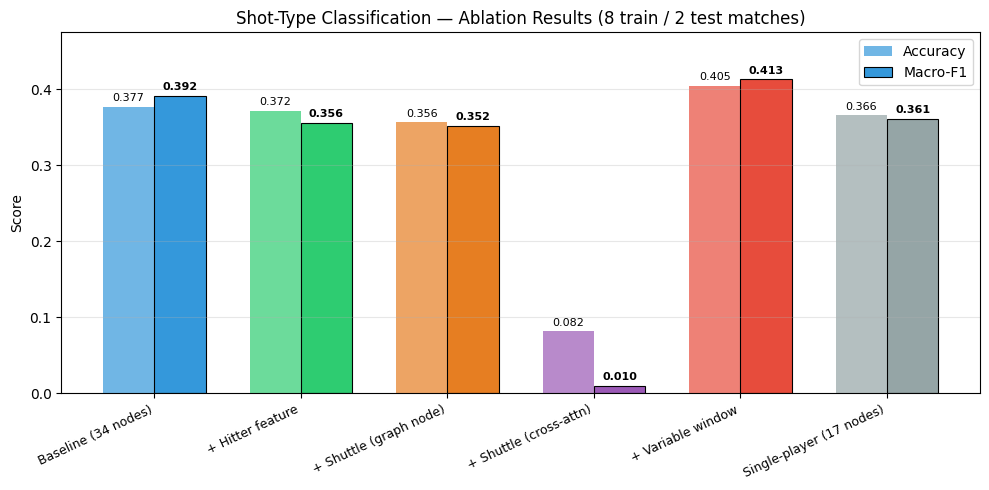

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/ablation_comparison.png


In [12]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

# Reload paths if needed
try:
    _abl_dir = ABLATION_DIR
except NameError:
    from src.config import RESULTS_DIR
    _abl_dir = RESULTS_DIR / 'ablations'

# Load all results
ablation_order = [
    'abl1_baseline',
    'abl2_hitter',
    'abl3a_shuttle_graph',
    'abl3b_shuttle_crossattn',
    'abl4_variable_window',
    'abl5_single_player',
]
display_names = [
    'Baseline (34 nodes)',
    '+ Hitter feature',
    '+ Shuttle (graph node)',
    '+ Shuttle (cross-attn)',
    '+ Variable window',
    'Single-player (17 nodes)',
]

results = []
for name in ablation_order:
    p = _abl_dir / f'{name}.json'
    if p.exists():
        with open(p) as f:
            results.append(json.load(f))
    else:
        results.append(None)

# ── Table ──────────────────────────────────────────────────────────────────
print('=' * 85)
print(f'{"#":<4} {"Ablation":<30} {"Accuracy":>10} {"Macro-F1":>10} {"Epochs":>8} {"Time":>8}')
print('-' * 85)
best_f1 = max((r['macro_f1'] for r in results if r), default=0)
for i, (name, dname, r) in enumerate(zip(ablation_order, display_names, results), 1):
    if r is None:
        print(f'{i:<4} {dname:<30} {"(not run)":>10}')
    else:
        marker = ' <-- best' if r['macro_f1'] == best_f1 else ''
        print(f'{i:<4} {dname:<30} {r["accuracy"]:>10.4f} {r["macro_f1"]:>10.4f} '
              f'{r["stopped_epoch"]:>8} {r["train_time_s"]:>7.0f}s{marker}')
print('=' * 85)

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names_plot = []
f1_plot = []
acc_plot = []
colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c', '#95a5a6']

for dname, r, c in zip(display_names, results, colors):
    if r is not None:
        names_plot.append(dname)
        f1_plot.append(r['macro_f1'])
        acc_plot.append(r['accuracy'])

x = np.arange(len(names_plot))
w = 0.35
bars1 = ax.bar(x - w/2, acc_plot, w, label='Accuracy', color=colors[:len(x)], alpha=0.7)
bars2 = ax.bar(x + w/2, f1_plot, w, label='Macro-F1', color=colors[:len(x)], edgecolor='black', linewidth=0.8)

for bar, val in zip(bars1, acc_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, f1_plot):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names_plot, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_title('Shot-Type Classification — Ablation Results (8 train / 2 test matches)')
ax.legend()
ax.set_ylim(0, max(acc_plot + f1_plot) * 1.15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

fig_path = _abl_dir / 'ablation_comparison.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

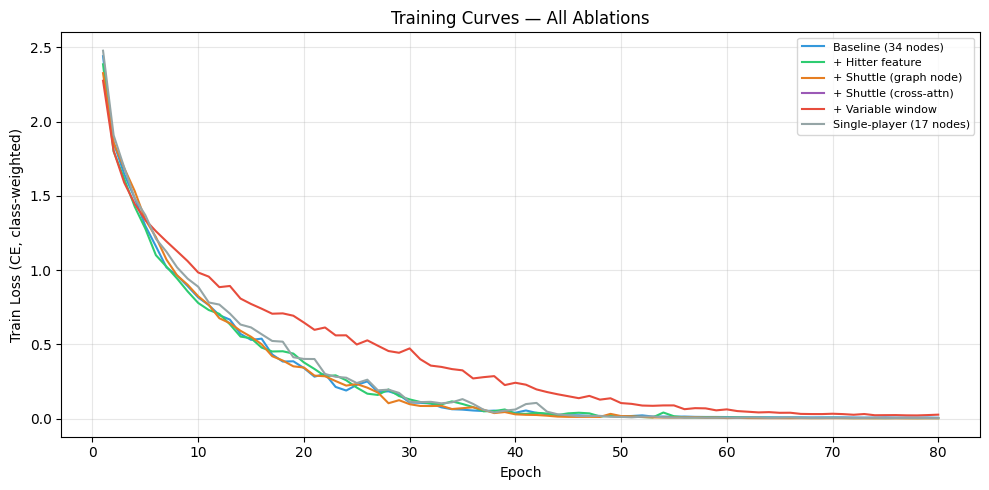

Saved: /content/drive/MyDrive/Baddiev2/results/ablations/ablation_training_curves.png


In [13]:
# ── Training curves overlay ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for dname, r, c in zip(display_names, results, colors):
    if r is not None and 'history' in r:
        losses = r['history']['train_loss']
        ax.plot(range(1, len(losses)+1), losses, label=dname, color=c, linewidth=1.5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Train Loss (CE, class-weighted)')
ax.set_title('Training Curves — All Ablations')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path2 = _abl_dir / 'ablation_training_curves.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')